In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = '/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(base + 'train.csv.zip', parse_dates=['Date'])
test = pd.read_csv(base + 'test.csv.zip', parse_dates=['Date'])
features = pd.read_csv(base + 'features.csv.zip', parse_dates=['Date'])
stores = pd.read_csv(base + 'stores.csv')

print(train.shape, test.shape, features.shape, stores.shape)
train.head()

(421570, 5) (115064, 4) (8190, 12) (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
for name, df in [('train', train), ('test', test), ('features', features), ('stores', stores)]:
    print(f"--- {name} ---")
    print(df.shape)
    print(df.dtypes)
    print(df.isnull().sum())
    print()

--- train ---
(421570, 5)
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

--- test ---
(115064, 4)
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object
Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64

--- features ---
(8190, 12)
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object
Store              0
Date               0
Temperature        0

In [3]:
print("Stores in train:", train['Store'].nunique())
print("Stores in stores.csv:", stores['Store'].nunique())
print("Dates in train:", train['Date'].nunique())
print("Dates in features:", features['Date'].nunique())

train_dates = set(zip(train['Store'], train['Date']))
feat_dates = set(zip(features['Store'], features['Date']))
print("Train (Store,Date) pairs missing from features:", len(train_dates - feat_dates))

Stores in train: 45
Stores in stores.csv: 45
Dates in train: 143
Dates in features: 182
Train (Store,Date) pairs missing from features: 0


In [4]:
train_full = train.merge(features, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
train_full = train_full.merge(stores, on='Store', how='left')

print(train_full.isnull().sum())

Store                  0
Dept                   0
Date                   0
Weekly_Sales           0
IsHoliday              0
Temperature            0
Fuel_Price             0
MarkDown1         270889
MarkDown2         310322
MarkDown3         284479
MarkDown4         286603
MarkDown5         270138
CPI                    0
Unemployment           0
IsHoliday_feat         0
Type                   0
Size                   0
dtype: int64


In [5]:
print((train_full['IsHoliday'] != train_full['IsHoliday_feat']).sum())

0


In [6]:
train_full = train_full.drop(columns=['IsHoliday_feat'])

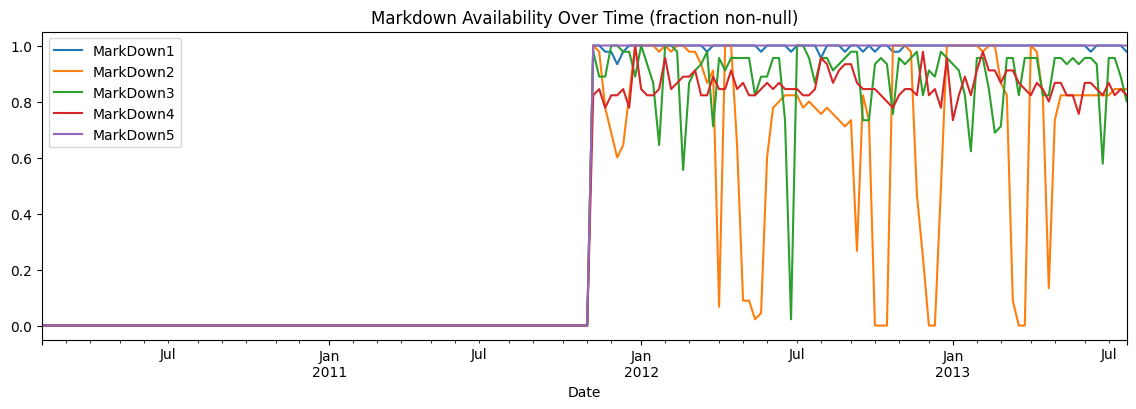

In [7]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
md_by_date = features.groupby('Date')[markdown_cols].apply(lambda x: x.notnull().mean())
md_by_date.plot(figsize=(14, 4), title='Markdown Availability Over Time (fraction non-null)')
plt.show()

In [8]:
test_full = test.merge(features, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
test_full = test_full.merge(stores, on='Store', how='left')
test_full = test_full.drop(columns=['IsHoliday_feat'])

print(test_full.isnull().sum())

Store               0
Dept                0
Date                0
IsHoliday           0
Temperature         0
Fuel_Price          0
MarkDown1         149
MarkDown2       28627
MarkDown3        9829
MarkDown4       12888
MarkDown5           0
CPI             38162
Unemployment    38162
Type                0
Size                0
dtype: int64


In [9]:
missing_cpi_dates = features[features['CPI'].isnull()]['Date'].unique()
print(sorted(missing_cpi_dates))
print(features['Date'].max(), test['Date'].max())

[Timestamp('2013-05-03 00:00:00'), Timestamp('2013-05-10 00:00:00'), Timestamp('2013-05-17 00:00:00'), Timestamp('2013-05-24 00:00:00'), Timestamp('2013-05-31 00:00:00'), Timestamp('2013-06-07 00:00:00'), Timestamp('2013-06-14 00:00:00'), Timestamp('2013-06-21 00:00:00'), Timestamp('2013-06-28 00:00:00'), Timestamp('2013-07-05 00:00:00'), Timestamp('2013-07-12 00:00:00'), Timestamp('2013-07-19 00:00:00'), Timestamp('2013-07-26 00:00:00')]
2013-07-26 00:00:00 2013-07-26 00:00:00


In [10]:
features_filled = features.copy()
features_filled = features_filled.sort_values(['Store', 'Date'])
features_filled[['CPI', 'Unemployment']] = (
    features_filled.groupby('Store')[['CPI', 'Unemployment']]
    .transform(lambda x: x.ffill())
)


print(features_filled[['CPI', 'Unemployment']].isnull().sum())

CPI             0
Unemployment    0
dtype: int64


In [11]:
train_full = train.merge(features_filled, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
train_full = train_full.merge(stores, on='Store', how='left')
train_full = train_full.drop(columns=['IsHoliday_feat'])

test_full = test.merge(features_filled, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
test_full = test_full.merge(stores, on='Store', how='left')
test_full = test_full.drop(columns=['IsHoliday_feat'])

print("train_full nulls:\n", train_full.isnull().sum())
print("\ntest_full nulls:\n", test_full.isnull().sum())

train_full nulls:
 Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

test_full nulls:
 Store               0
Dept                0
Date                0
IsHoliday           0
Temperature         0
Fuel_Price          0
MarkDown1         149
MarkDown2       28627
MarkDown3        9829
MarkDown4       12888
MarkDown5           0
CPI                 0
Unemployment        0
Type                0
Size                0
dtype: int64


In [12]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

train_full[markdown_cols] = train_full[markdown_cols].fillna(0)
test_full[markdown_cols] = test_full[markdown_cols].fillna(0)

# confirm zero nulls everywhere
print(train_full.isnull().sum().sum()) 
print(test_full.isnull().sum().sum())   

0
0


In [13]:
train_full.to_parquet('train_clean.parquet', index=False)
test_full.to_parquet('test_clean.parquet', index=False)

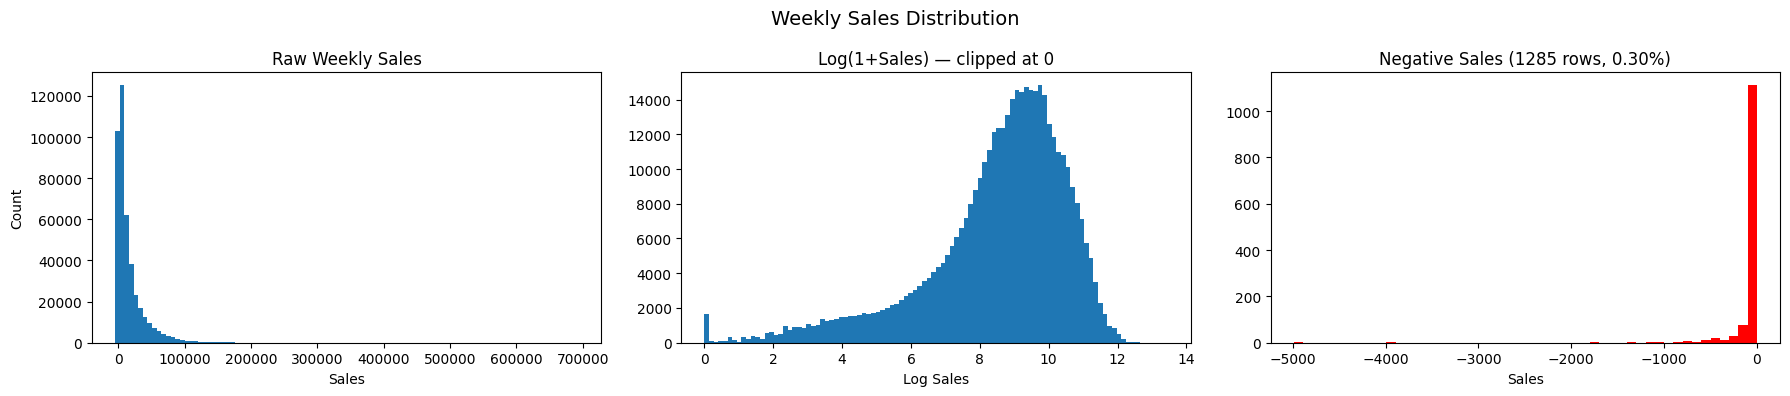

Total rows: 421570
Negative sales rows: 1285 (0.30%)
Min: -4988.94
Max: 693099.36
Mean: 15981.26
Median: 7612.03


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Weekly Sales Distribution', fontsize=14)

# raw distribution
axes[0].hist(train_full['Weekly_Sales'], bins=100, edgecolor='none')
axes[0].set_title('Raw Weekly Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count')

# log transformed
axes[1].hist(np.log1p(train_full['Weekly_Sales'].clip(lower=0)), bins=100, edgecolor='none')
axes[1].set_title('Log(1+Sales) — clipped at 0')
axes[1].set_xlabel('Log Sales')

# negative sales
neg = train_full[train_full['Weekly_Sales'] < 0]
axes[2].hist(neg['Weekly_Sales'], bins=50, color='red', edgecolor='none')
axes[2].set_title(f'Negative Sales ({len(neg)} rows, {len(neg)/len(train_full)*100:.2f}%)')
axes[2].set_xlabel('Sales')

plt.tight_layout()
plt.show()

print(f"Total rows: {len(train_full)}")
print(f"Negative sales rows: {len(neg)} ({len(neg)/len(train_full)*100:.2f}%)")
print(f"Min: {train_full['Weekly_Sales'].min():.2f}")
print(f"Max: {train_full['Weekly_Sales'].max():.2f}")
print(f"Mean: {train_full['Weekly_Sales'].mean():.2f}")
print(f"Median: {train_full['Weekly_Sales'].median():.2f}")

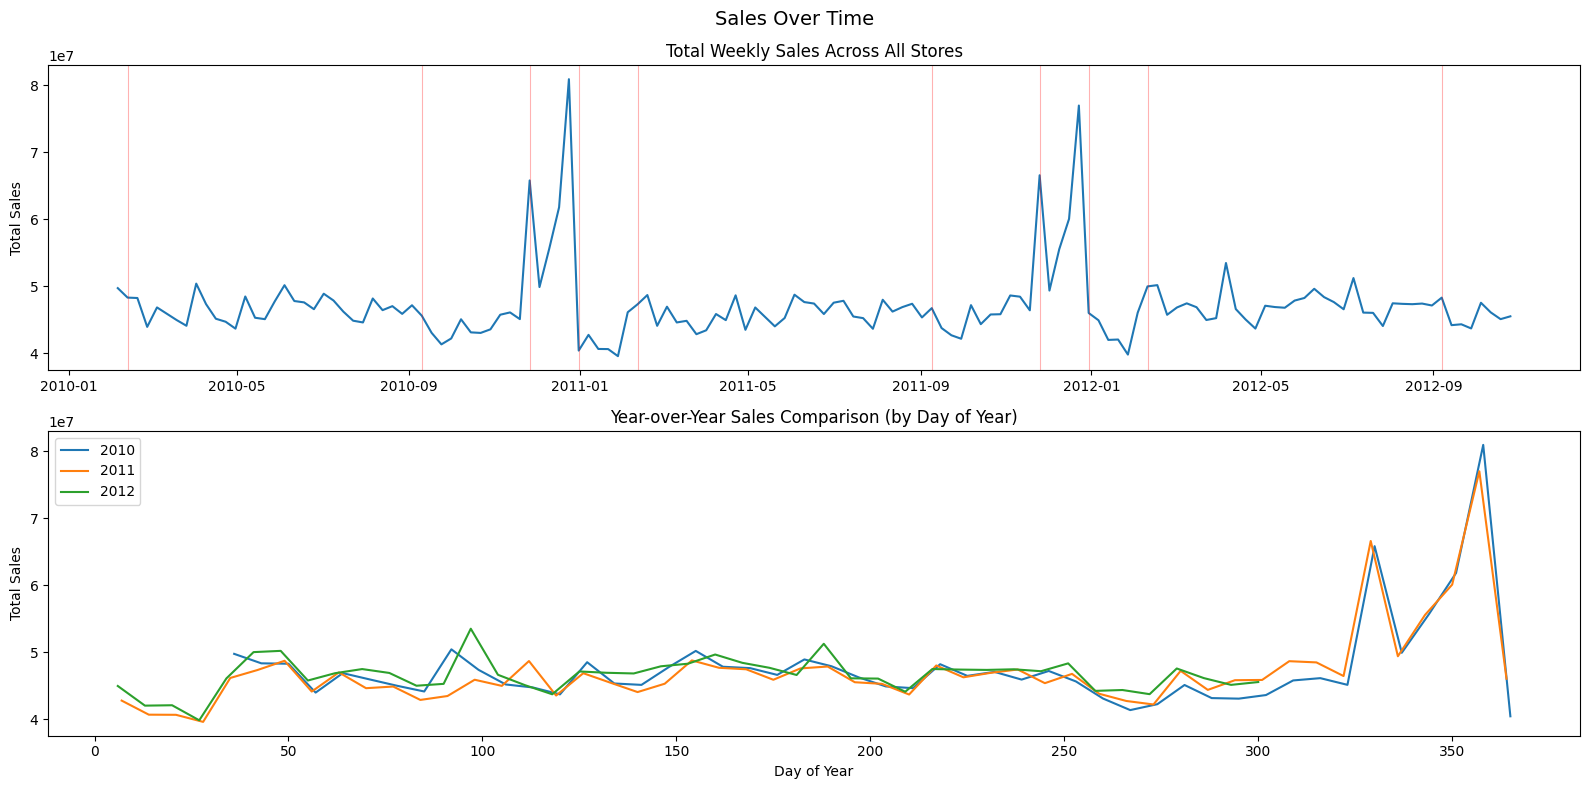

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Sales Over Time', fontsize=14)

weekly_agg = train_full.groupby('Date')['Weekly_Sales'].sum().reset_index()

# total sales over time
axes[0].plot(weekly_agg['Date'], weekly_agg['Weekly_Sales'])
axes[0].set_title('Total Weekly Sales Across All Stores')
axes[0].set_ylabel('Total Sales')

# highlight holiday weeks
holiday_dates = train_full[train_full['IsHoliday']]['Date'].unique()
for d in holiday_dates:
    axes[0].axvline(d, color='red', alpha=0.3, linewidth=0.8)

# year over year comparison
for year in [2010, 2011, 2012]:
    yearly = train_full[train_full['Date'].dt.year == year].groupby('Date')['Weekly_Sales'].sum()
    axes[1].plot(yearly.index.dayofyear, yearly.values, label=str(year))
axes[1].set_title('Year-over-Year Sales Comparison (by Day of Year)')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Total Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

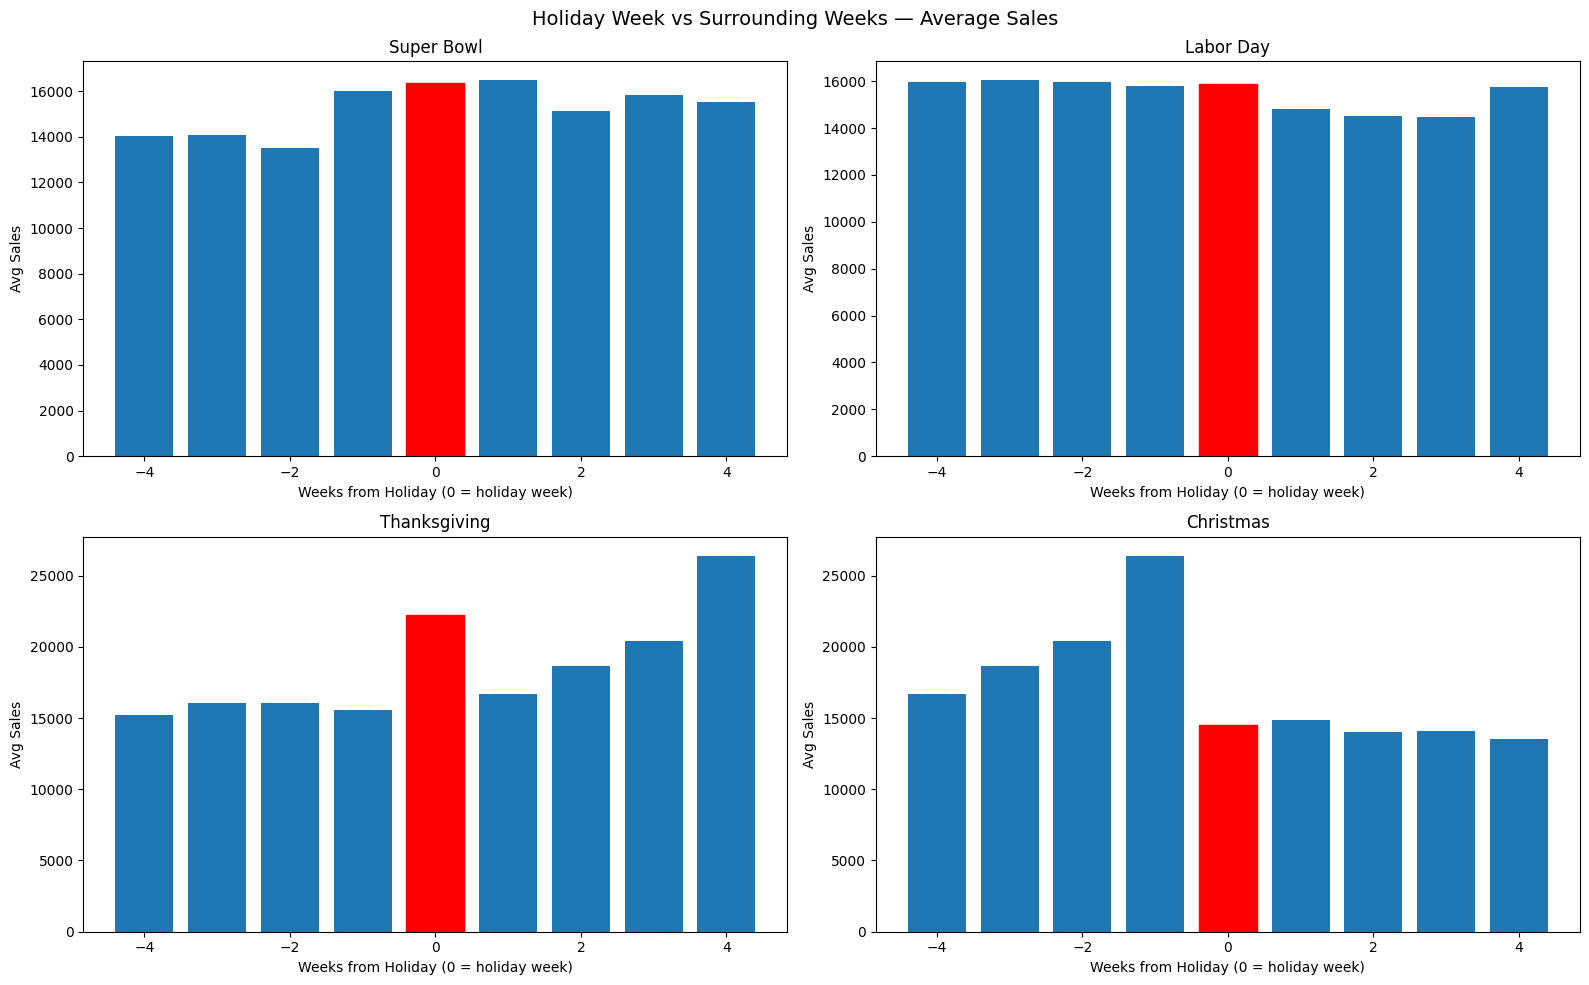

In [16]:
holiday_map = {
    'Super Bowl':    ['2010-02-12', '2011-02-11', '2012-02-10'],
    'Labor Day':     ['2010-09-10', '2011-09-09', '2012-09-07'],
    'Thanksgiving':  ['2010-11-26', '2011-11-25', '2012-11-23'],
    'Christmas':     ['2010-12-31', '2011-12-30', '2012-12-28'],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Holiday Week vs Surrounding Weeks — Average Sales', fontsize=14)

for ax, (holiday, dates) in zip(axes.flatten(), holiday_map.items()):
    dates = pd.to_datetime(dates)
    windows = []
    for d in dates:
        # 4 weeks before and after each holiday
        window = train_full[
            (train_full['Date'] >= d - pd.Timedelta(weeks=4)) &
            (train_full['Date'] <= d + pd.Timedelta(weeks=4))
        ].copy()
        window['weeks_from_holiday'] = ((window['Date'] - d).dt.days / 7).round().astype(int)
        windows.append(window)
    
    combined = pd.concat(windows)
    avg = combined.groupby('weeks_from_holiday')['Weekly_Sales'].mean()
    
    bars = ax.bar(avg.index, avg.values)
    for i, bar in enumerate(bars):
        if avg.index[i] == 0:
            bar.set_color('red')
    ax.set_title(holiday)
    ax.set_xlabel('Weeks from Holiday (0 = holiday week)')
    ax.set_ylabel('Avg Sales')

plt.tight_layout()
plt.show()

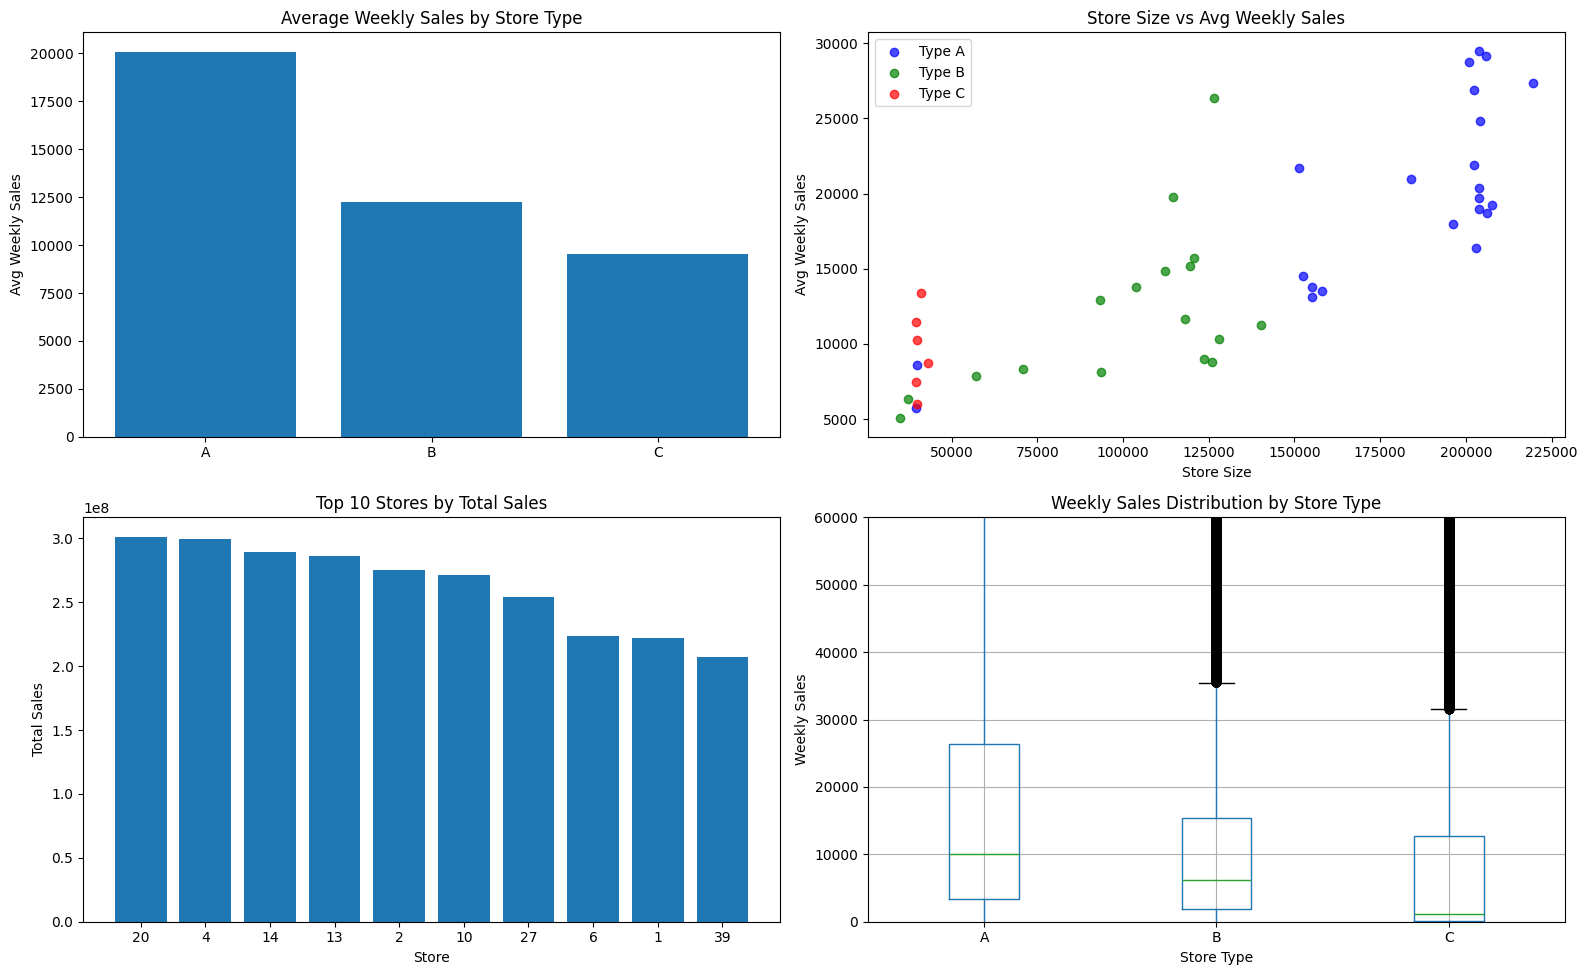

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Store Analysis', fontsize=14)

# sales by store type
store_type_sales = train_full.groupby('Type')['Weekly_Sales'].mean()
axes[0][0].bar(store_type_sales.index, store_type_sales.values)
axes[0][0].set_title('Average Weekly Sales by Store Type')
axes[0][0].set_ylabel('Avg Weekly Sales')

# sales by store size
store_avg = train_full.groupby('Store').agg(
    avg_sales=('Weekly_Sales', 'mean'),
    size=('Size', 'first'),
    type=('Type', 'first')
).reset_index()
colors = {'A': 'blue', 'B': 'green', 'C': 'red'}
for t, grp in store_avg.groupby('type'):
    axes[0][1].scatter(grp['size'], grp['avg_sales'], label=f'Type {t}', 
                       color=colors[t], alpha=0.7)
axes[0][1].set_title('Store Size vs Avg Weekly Sales')
axes[0][1].set_xlabel('Store Size')
axes[0][1].set_ylabel('Avg Weekly Sales')
axes[0][1].legend()

# top 10 stores by total sales
top_stores = train_full.groupby('Store')['Weekly_Sales'].sum().nlargest(10)
axes[1][0].bar(top_stores.index.astype(str), top_stores.values)
axes[1][0].set_title('Top 10 Stores by Total Sales')
axes[1][0].set_xlabel('Store')
axes[1][0].set_ylabel('Total Sales')

# sales distribution per store type boxplot
train_full.boxplot(column='Weekly_Sales', by='Type', ax=axes[1][1])
axes[1][1].set_ylim(0, 60000)
axes[1][1].set_title('Weekly Sales Distribution by Store Type')
axes[1][1].set_xlabel('Store Type')
axes[1][1].set_ylabel('Weekly Sales')
plt.suptitle('')

plt.tight_layout()
plt.show()

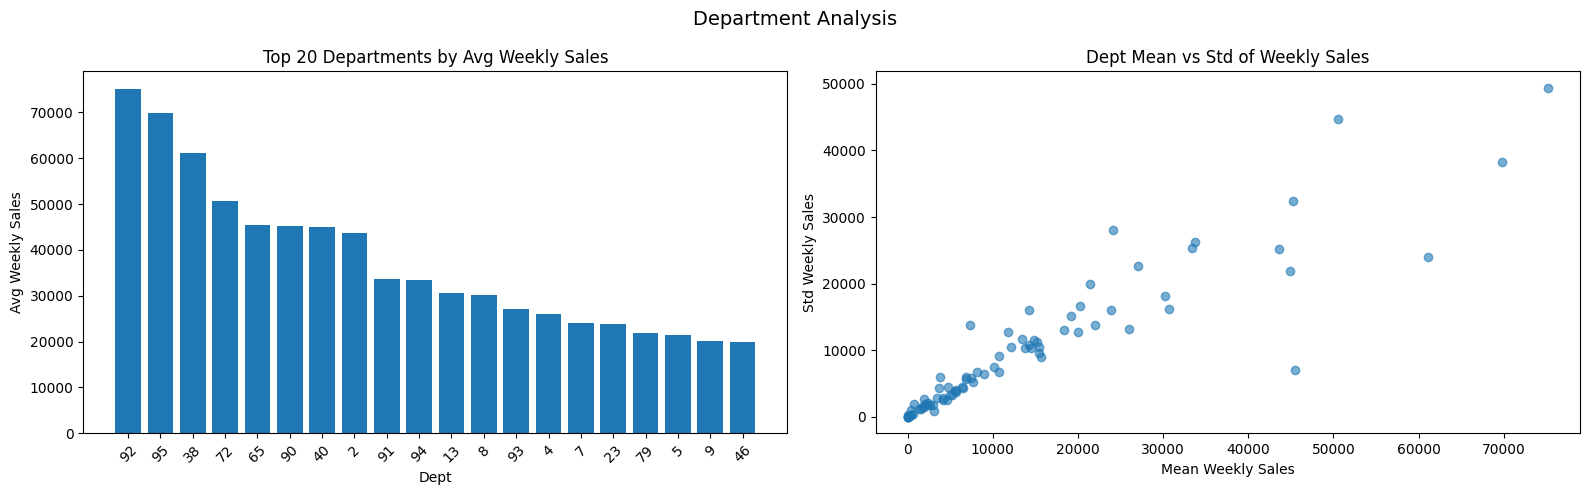

Departments with avg weekly sales < 1000: 0
Series([], Name: Weekly_Sales, dtype: float64)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Department Analysis', fontsize=14)

# top 20 departments by average sales
dept_avg = train_full.groupby('Dept')['Weekly_Sales'].mean().nlargest(20)
axes[0].bar(dept_avg.index.astype(str), dept_avg.values)
axes[0].set_title('Top 20 Departments by Avg Weekly Sales')
axes[0].set_xlabel('Dept')
axes[0].set_ylabel('Avg Weekly Sales')
axes[0].tick_params(axis='x', rotation=45)

# department sales spread — how much variance is there between depts?
dept_stats = train_full.groupby('Dept')['Weekly_Sales'].agg(['mean', 'std']).reset_index()
axes[1].scatter(dept_stats['mean'], dept_stats['std'], alpha=0.6)
axes[1].set_title('Dept Mean vs Std of Weekly Sales')
axes[1].set_xlabel('Mean Weekly Sales')
axes[1].set_ylabel('Std Weekly Sales')

plt.tight_layout()
plt.show()

# how many depts are near-zero volume (sparse series)
sparse_depts = dept_avg[dept_avg < 1000]
print(f"Departments with avg weekly sales < 1000: {len(sparse_depts)}")
print(sparse_depts)

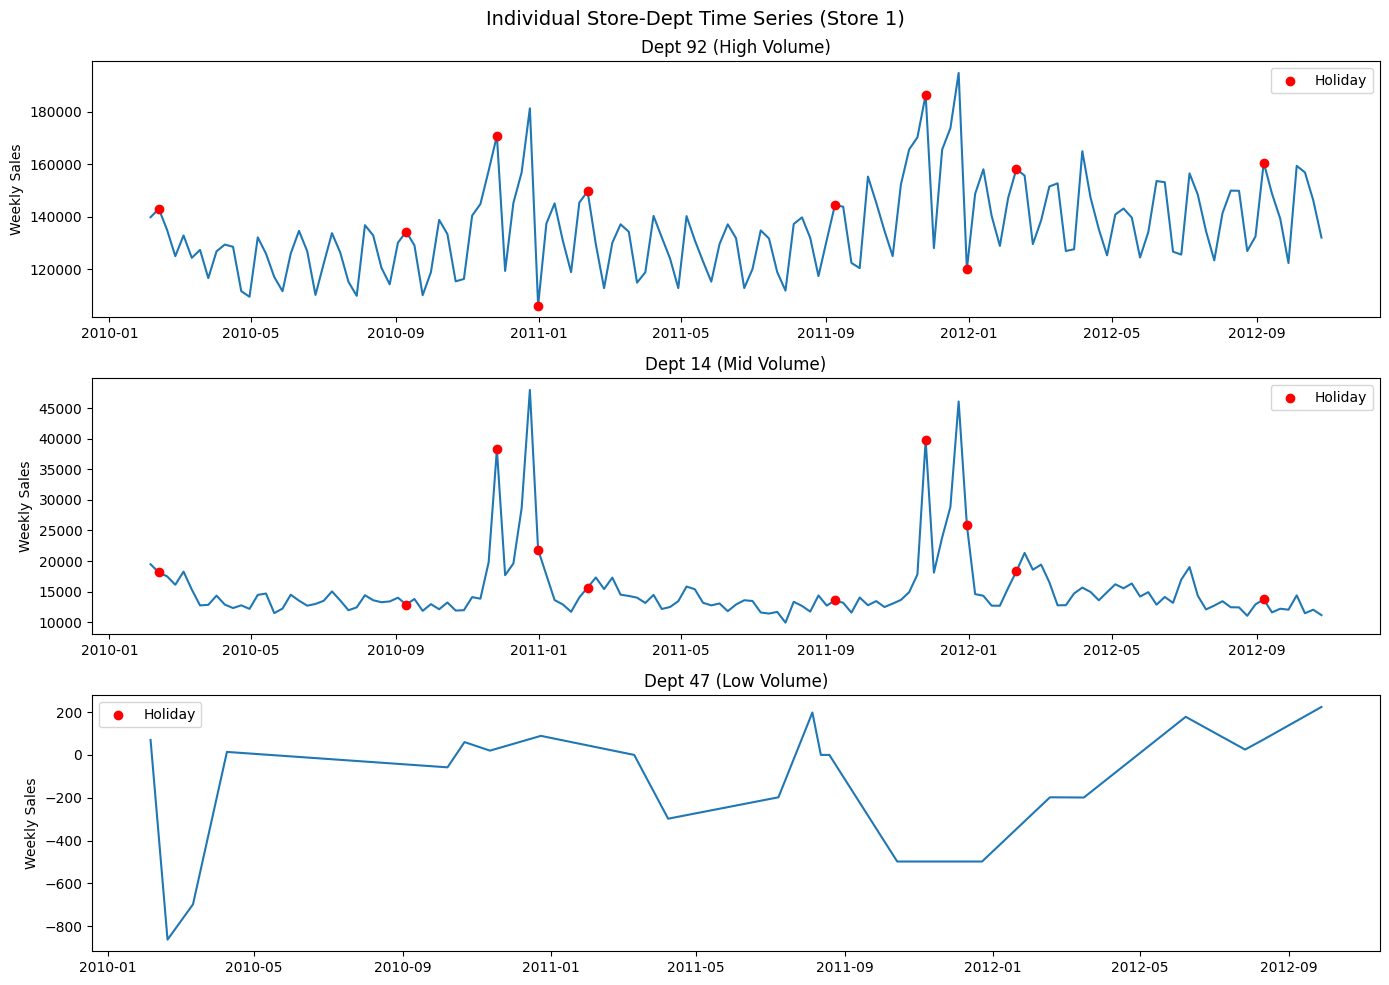

In [19]:
# pick high volume, medium volume, low volume depts
top_dept = train_full.groupby('Dept')['Weekly_Sales'].mean().idxmax()
mid_dept = 14  # typically grocery/food, usually mid-range
low_dept = train_full.groupby('Dept')['Weekly_Sales'].mean().nsmallest(5).index[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Individual Store-Dept Time Series (Store 1)', fontsize=14)

for ax, dept, label in zip(axes, 
                            [top_dept, mid_dept, low_dept], 
                            ['High Volume', 'Mid Volume', 'Low Volume']):
    s = train_full[(train_full['Store'] == 1) & 
                   (train_full['Dept'] == dept)].sort_values('Date')
    if len(s) == 0:
        ax.set_title(f'Dept {dept} ({label}) — not in Store 1')
        continue
    ax.plot(s['Date'], s['Weekly_Sales'])
    # mark holiday weeks
    hol = s[s['IsHoliday']]
    ax.scatter(hol['Date'], hol['Weekly_Sales'], color='red', zorder=5, label='Holiday')
    ax.set_title(f'Dept {dept} ({label})')
    ax.set_ylabel('Weekly Sales')
    ax.legend()

plt.tight_layout()
plt.show()

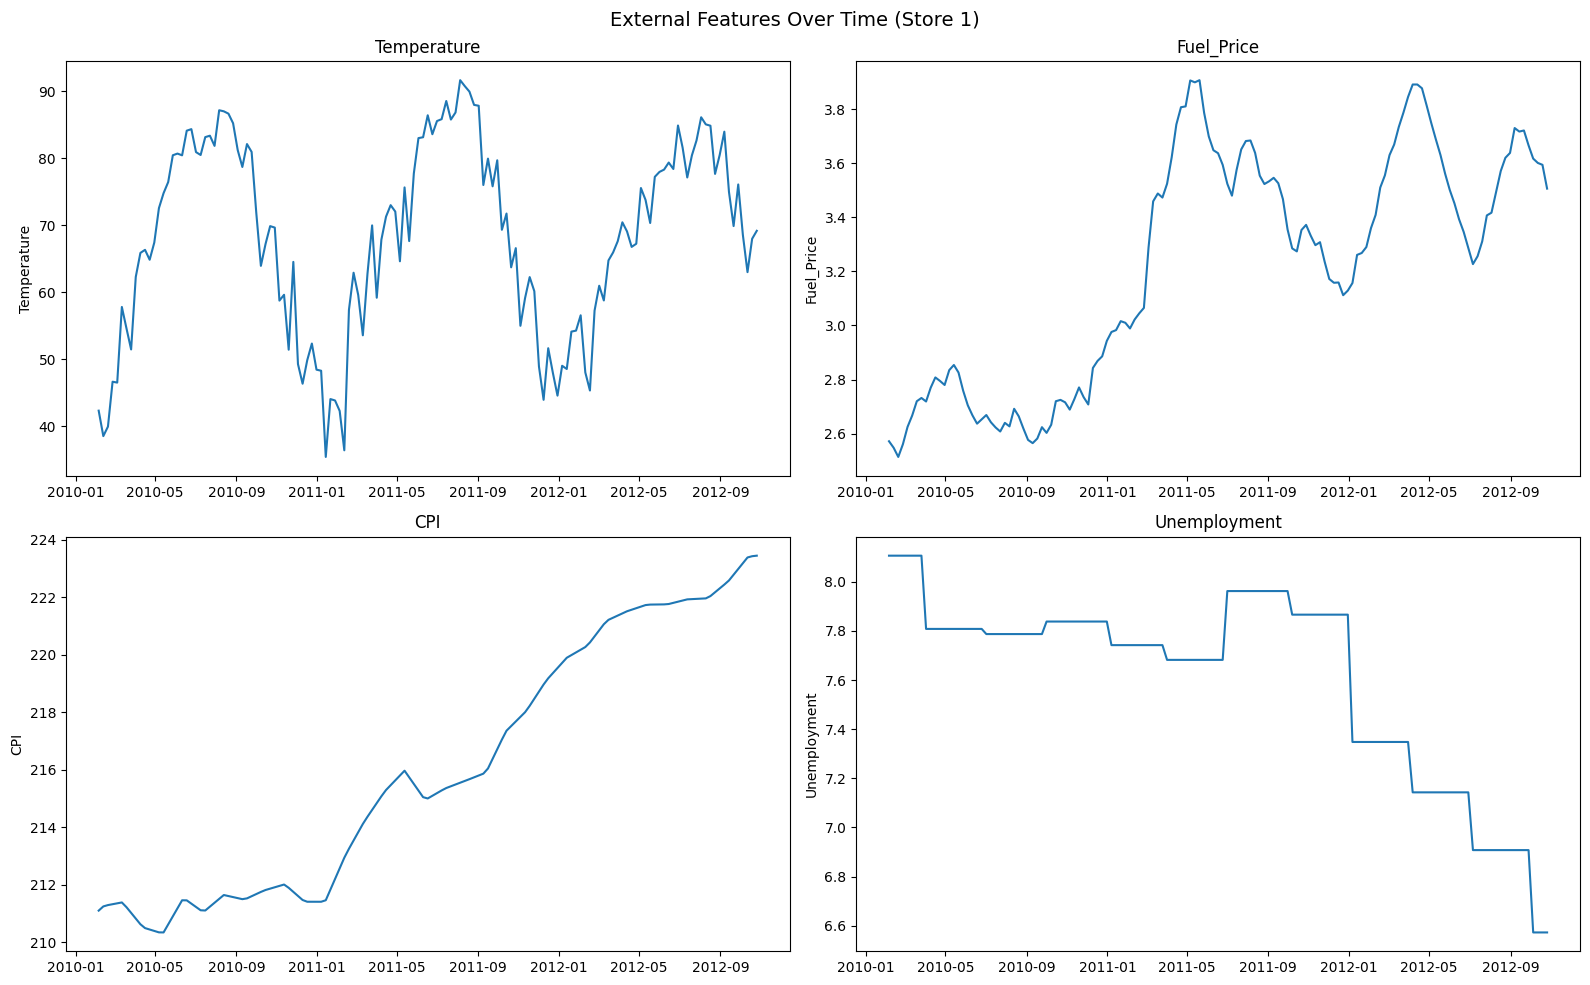

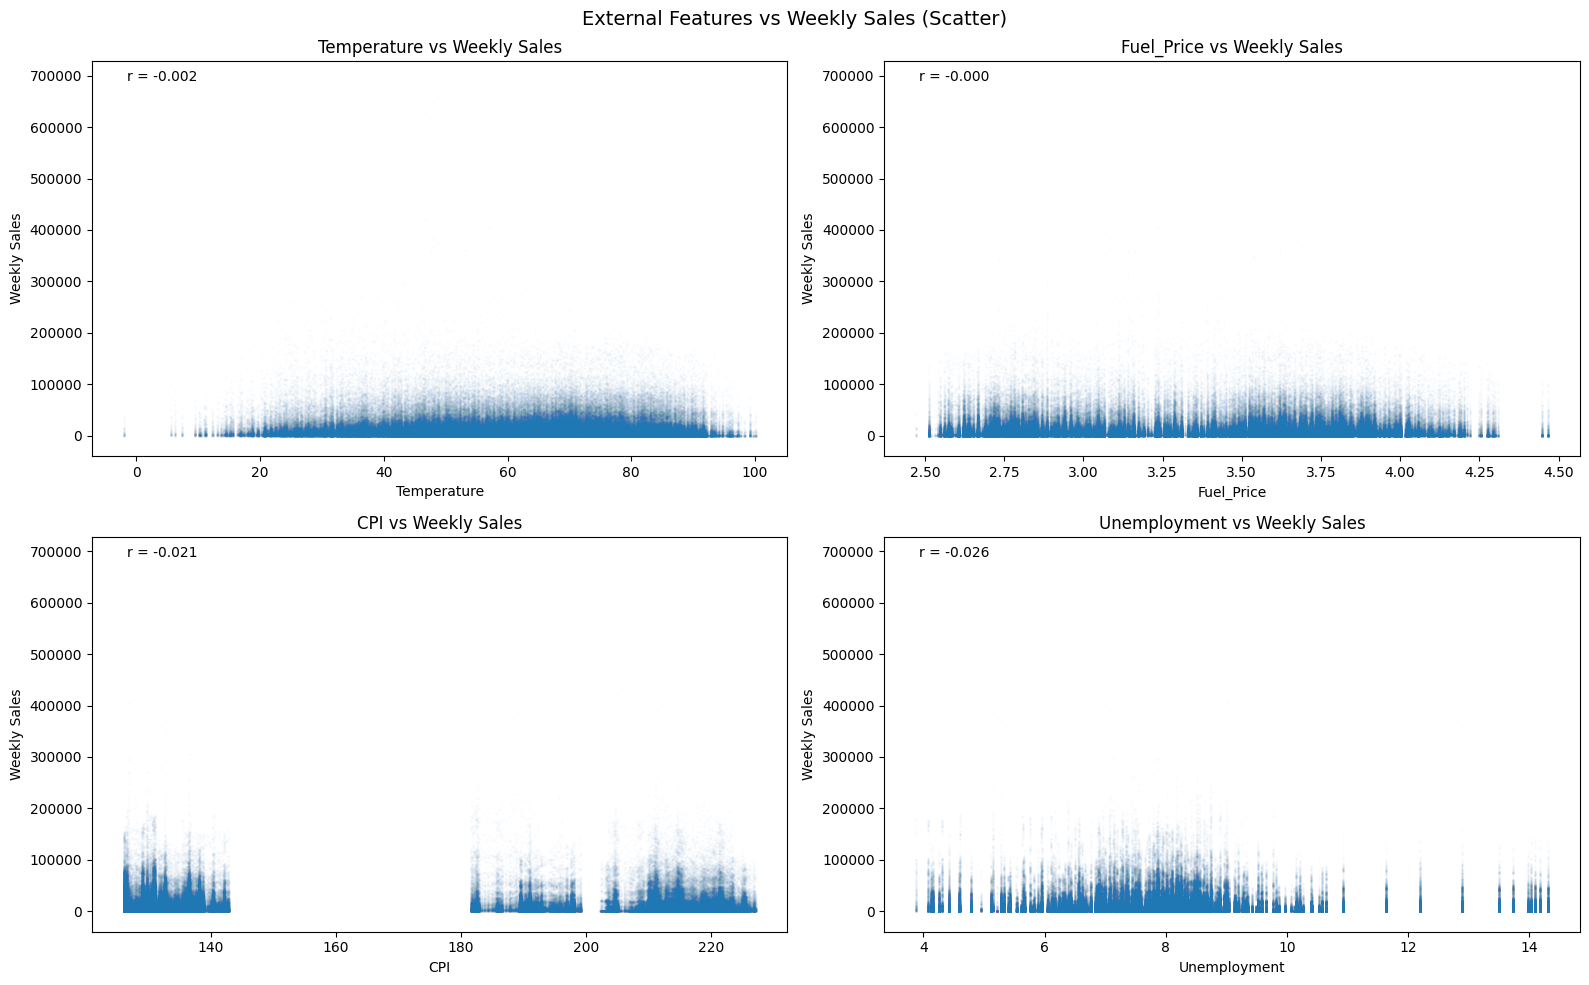

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('External Features Over Time (Store 1)', fontsize=14)

store1 = train_full[train_full['Store'] == 1].sort_values('Date')

for ax, col in zip(axes.flatten(), ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']):
    ax.plot(store1['Date'], store1[col])
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# correlation of external features with weekly sales
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('External Features vs Weekly Sales (Scatter)', fontsize=14)

for ax, col in zip(axes.flatten(), ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']):
    ax.scatter(train_full[col], train_full['Weekly_Sales'], alpha=0.01, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('Weekly Sales')
    ax.set_title(f'{col} vs Weekly Sales')
    corr = train_full[col].corr(train_full['Weekly_Sales'])
    ax.annotate(f'r = {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.show()

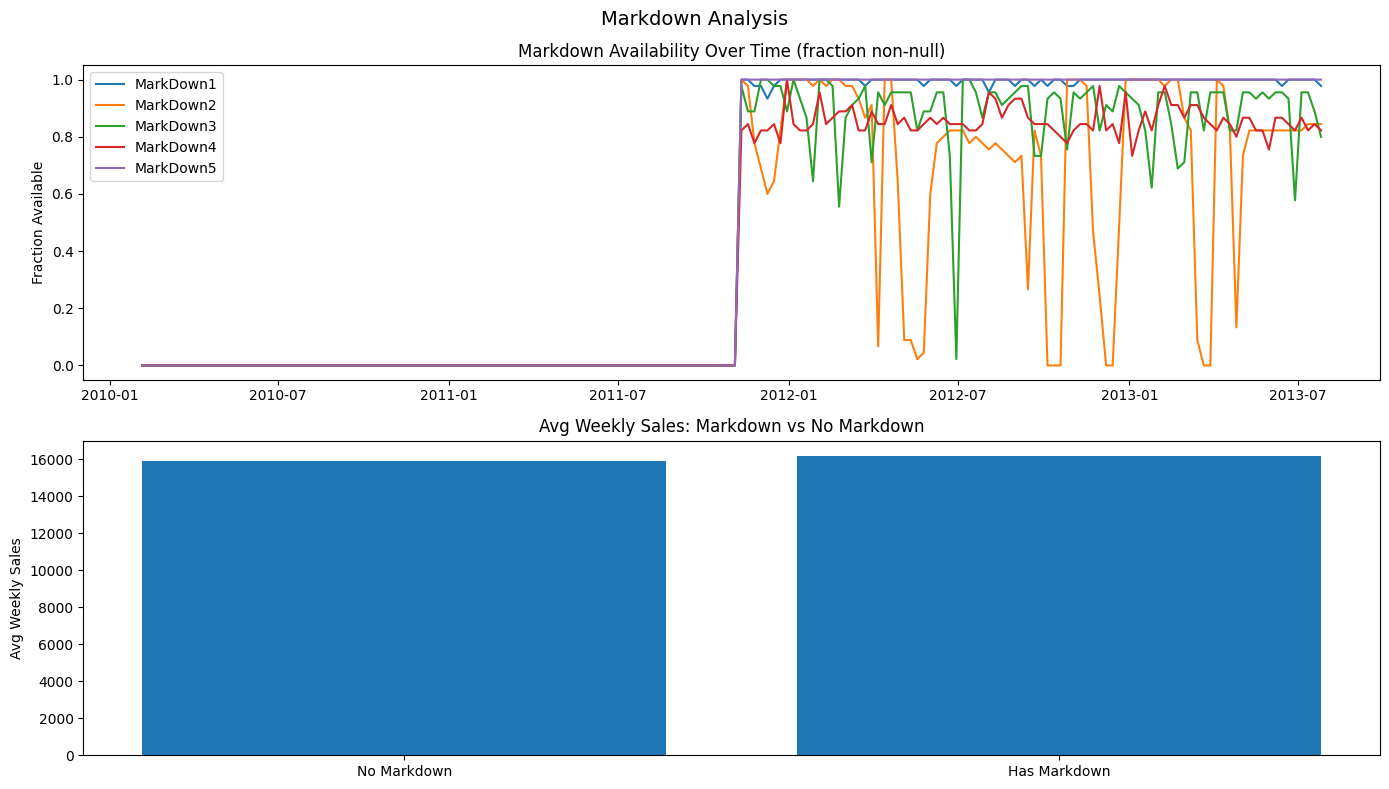

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Markdown Analysis', fontsize=14)

# availability over time (justifies zero-fill decision)
md_by_date = features.groupby('Date')[markdown_cols].apply(lambda x: x.notnull().mean())
for col in markdown_cols:
    axes[0].plot(md_by_date.index, md_by_date[col], label=col)
axes[0].set_title('Markdown Availability Over Time (fraction non-null)')
axes[0].set_ylabel('Fraction Available')
axes[0].legend()

# markdown vs no markdown sales comparison
train_full['any_markdown'] = (train_full[markdown_cols] > 0).any(axis=1)
md_comp = train_full.groupby('any_markdown')['Weekly_Sales'].mean()
axes[1].bar(['No Markdown', 'Has Markdown'], md_comp.values)
axes[1].set_title('Avg Weekly Sales: Markdown vs No Markdown')
axes[1].set_ylabel('Avg Weekly Sales')

plt.tight_layout()
plt.show()

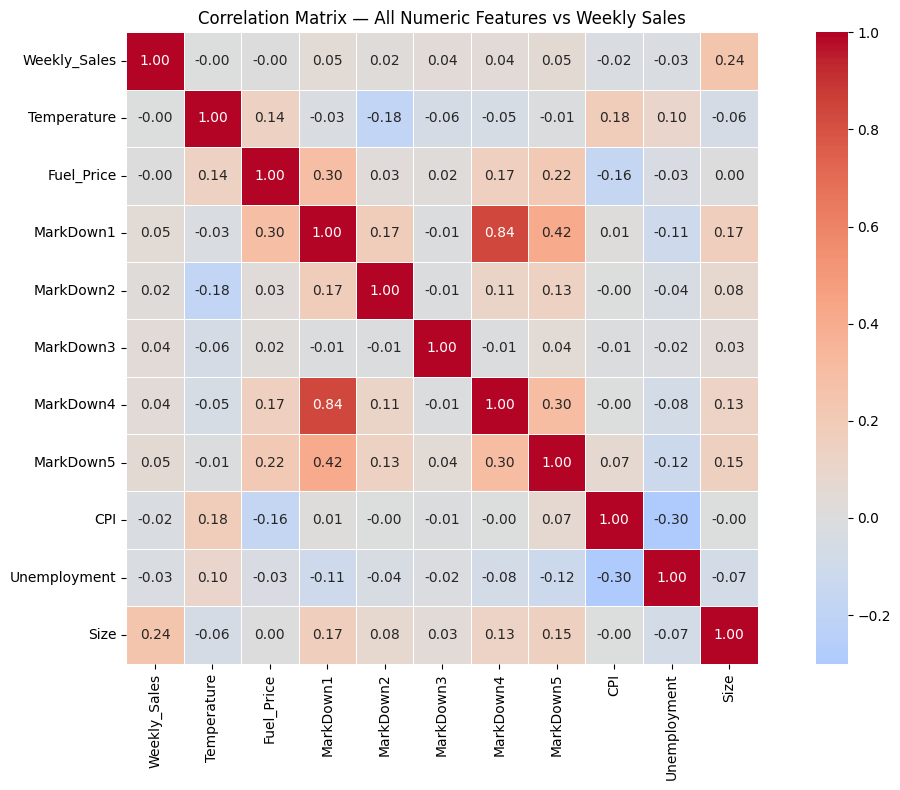

In [22]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                'CPI', 'Unemployment', 'Size']

corr = train_full[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — All Numeric Features vs Weekly Sales')
plt.tight_layout()
plt.show()

Upper fence (3x IQR): 74584
Outliers above fence: 12830 (3.04%)

Which depts contain most outliers:
Dept
92    2761
95    2426
38    1793
90    1332
72    1000
2      820
40     678
91     548
94     282
8      231
Name: count, dtype: int64

Negative sales: 1285
Zero sales: 73


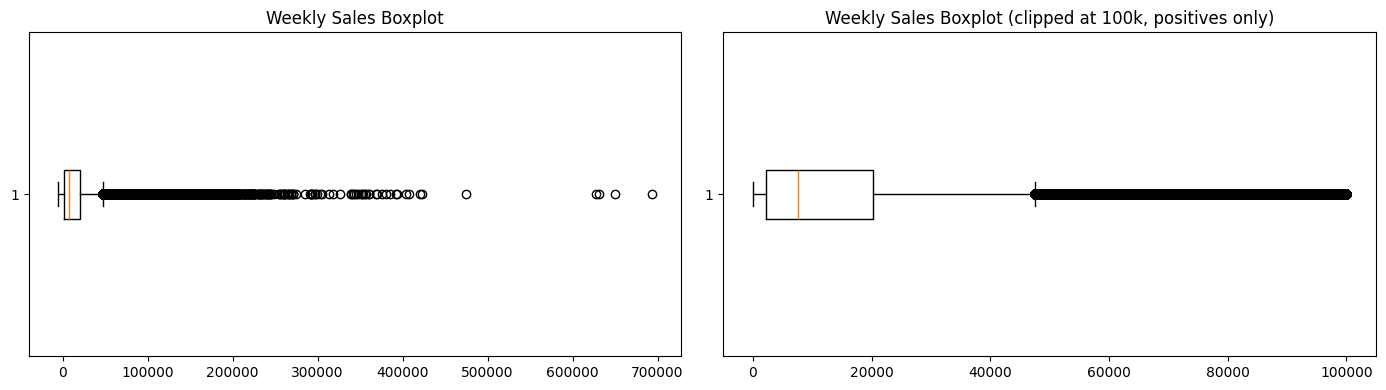

In [23]:
# change train_fe to train_full throughout
Q1 = train_full['Weekly_Sales'].quantile(0.25)
Q3 = train_full['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

outliers = train_full[train_full['Weekly_Sales'] > upper_fence]
print(f"Upper fence (3x IQR): {upper_fence:.0f}")
print(f"Outliers above fence: {len(outliers)} ({len(outliers)/len(train_full)*100:.2f}%)")
print(f"\nWhich depts contain most outliers:")
print(outliers['Dept'].value_counts().head(10))
print(f"\nNegative sales: {(train_full['Weekly_Sales'] < 0).sum()}")
print(f"Zero sales: {(train_full['Weekly_Sales'] == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(train_full['Weekly_Sales'], vert=False)
axes[0].set_title('Weekly Sales Boxplot')
axes[1].boxplot(train_full[train_full['Weekly_Sales'] > 0]['Weekly_Sales'].clip(upper=100000), vert=False)
axes[1].set_title('Weekly Sales Boxplot (clipped at 100k, positives only)')
plt.tight_layout()
plt.show()

In [24]:
print(f"Negative sales rows: {(train_full['Weekly_Sales'] < 0).sum()}")
print("Decision: keeping negative sales real returns data")
print("Decision: keeping extreme values legitimate holiday spikes")

Negative sales rows: 1285
Decision: keeping negative sales real returns data
Decision: keeping extreme values legitimate holiday spikes


In [25]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
train_full['any_markdown'] = (train_full[markdown_cols] > 0).any(axis=1).astype(int)
test_full['any_markdown']  = (test_full[markdown_cols] > 0).any(axis=1).astype(int)

In [26]:
def add_calendar_features(df):
    df = df.copy()
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['Week']       = df['Date'].dt.isocalendar().week.astype(int)
    df['DayOfYear']  = df['Date'].dt.dayofyear
    df['Quarter']    = df['Date'].dt.quarter
    df['Year_norm']  = df['Year'] - 2010  # 0,1,2 instead of 2010,2011,2012
    df['Week_sin']   = np.sin(2 * np.pi * df['Week'] / 52)
    df['Week_cos']   = np.cos(2 * np.pi * df['Week'] / 52)
    df['Month_sin']  = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos']  = np.cos(2 * np.pi * df['Month'] / 12)
    return df

train_full = add_calendar_features(train_full)
test_full  = add_calendar_features(test_full)
print("✓ Calendar features done")

✓ Calendar features done


In [27]:
super_bowl   = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day    = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas    = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

def weeks_to_nearest(date, holiday_dates):
    diffs = [(date - h).days / 7 for h in holiday_dates]
    return min(diffs, key=abs)

def add_holiday_proximity(df):
    df = df.copy()
    for name, dates in [('SuperBowl', super_bowl), ('LaborDay', labor_day),
                         ('Thanksgiving', thanksgiving), ('Christmas', christmas)]:
        df[f'weeks_to_{name}'] = df['Date'].apply(lambda d: weeks_to_nearest(d, dates))
        df[f'near_{name}']     = (df[f'weeks_to_{name}'].abs() <= 2).astype(int)
    df['is_super_bowl']   = df['Date'].isin(super_bowl).astype(int)
    df['is_labor_day']    = df['Date'].isin(labor_day).astype(int)
    df['is_thanksgiving'] = df['Date'].isin(thanksgiving).astype(int)
    df['is_christmas']    = df['Date'].isin(christmas).astype(int)
    return df

train_full = add_holiday_proximity(train_full)
test_full  = add_holiday_proximity(test_full)
print("✓ Holiday proximity features done")

✓ Holiday proximity features done


In [28]:
def add_store_dept_features(df):
    df = df.copy()
    df['Type_enc']  = df['Type'].map({'A': 2, 'B': 1, 'C': 0})
    df['Size_log']  = np.log1p(df['Size'])
    df['Store_Dept'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
    return df

train_full = add_store_dept_features(train_full)
test_full  = add_store_dept_features(test_full)
print("✓ Store/dept features done")

✓ Store/dept features done


In [29]:
# Lag + rolling features 
# IMPORTANT: must compute on train+test together so test rows can 
# look back into train history
combined = pd.concat([
    train_full,
    test_full.assign(Weekly_Sales=np.nan)
], ignore_index=True).sort_values(['Store', 'Dept', 'Date'])

def add_lag_features(df):
    df = df.copy().sort_values(['Store', 'Dept', 'Date'])
    for lag in [1, 2, 3, 4, 5, 6, 12, 26, 52]:
        df[f'lag_{lag}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
    for window in [4, 8, 12, 26, 52]:
        grp = df.groupby(['Store', 'Dept'])['Weekly_Sales']
        df[f'rolling_mean_{window}'] = grp.shift(1).transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'rolling_std_{window}']  = grp.shift(1).transform(
            lambda x: x.rolling(window, min_periods=1).std())
        df[f'rolling_max_{window}']  = grp.shift(1).transform(
            lambda x: x.rolling(window, min_periods=1).max())
    df['expanding_mean'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).transform(
        lambda x: x.expanding(min_periods=1).mean())
    return df

combined = add_lag_features(combined)
train_fe = combined[combined['Weekly_Sales'].notna()].copy()
test_fe  = combined[combined['Weekly_Sales'].isna()].copy()
print(f"✓ Lag features done — train: {train_fe.shape}, test: {test_fe.shape}")

✓ Lag features done — train: (421570, 67), test: (115064, 67)


In [30]:
# Dept-level stats (fit on train only, apply to both) 
def add_dept_stats(train_df, apply_df):
    dept_avg = train_df.groupby('Dept')['Weekly_Sales'].mean().rename('dept_avg_sales')
    store_dept_avg = train_df.groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('store_dept_avg_sales')
    store_dept_week_avg = train_df.groupby(['Store','Dept','Week'])['Weekly_Sales'].mean().rename('store_dept_week_avg')
    
    df = apply_df.copy()
    df = df.join(dept_avg, on='Dept')
    df = df.join(store_dept_avg, on=['Store', 'Dept'])
    df = df.join(store_dept_week_avg, on=['Store', 'Dept', 'Week'])
    return df

train_fe = add_dept_stats(train_fe, train_fe)
test_fe  = add_dept_stats(train_fe, test_fe)
print("✓ Dept stats done")

✓ Dept stats done


In [31]:
def add_extra_features(train_df, apply_df):
    df = apply_df.copy()
    
    # drop if already exists (prevents conflict when train_df == apply_df)
    cols_to_drop = ['dept_holiday_sensitivity', 'store_dept_cv', 
                    'total_markdown', 'active_markdown_count', 'is_sparse_dept']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    holiday_sens = (
        train_df.groupby('Dept')
        .apply(lambda x: x[x['IsHoliday']]['Weekly_Sales'].mean() /
                         x[~x['IsHoliday']]['Weekly_Sales'].mean(),
               include_groups=False)
        .rename('dept_holiday_sensitivity')
    )
    df = df.join(holiday_sens, on='Dept')
    
    cv = (
        train_df.groupby(['Store', 'Dept'])['Weekly_Sales']
        .apply(lambda x: x.std() / x.mean() if x.mean() > 0 else 0,
               include_groups=False)
        .rename('store_dept_cv')
    )
    df = df.join(cv, on=['Store', 'Dept'])
    
    df['total_markdown']        = df[markdown_cols].sum(axis=1)
    df['active_markdown_count'] = (df[markdown_cols] > 0).sum(axis=1)
    
    dept_avg = train_df.groupby('Dept')['Weekly_Sales'].mean()
    df['is_sparse_dept'] = df['Dept'].map(dept_avg < 1000).astype(int)
    
    return df

train_fe = add_extra_features(train_fe, train_fe)
test_fe  = add_extra_features(train_fe, test_fe)
print("✓ Extra features done")

✓ Extra features done


In [32]:
# Fix cold start nulls in test 
test_fe['store_dept_avg_sales'] = test_fe['store_dept_avg_sales'].fillna(
    test_fe['dept_avg_sales'])
test_fe['store_dept_week_avg']  = test_fe['store_dept_week_avg'].fillna(
    test_fe['store_dept_avg_sales'])
print("✓ Cold start nulls fixed")

✓ Cold start nulls fixed


In [33]:
# ADD THESE before your final save cell

# 1. directional holiday flags
for name in ['SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas']:
    train_fe[f'before_{name}'] = (train_fe[f'weeks_to_{name}'] < 0).astype(int)
    test_fe[f'before_{name}']  = (test_fe[f'weeks_to_{name}'] < 0).astype(int)

# 2. store level average
store_avg = train_fe.groupby('Store')['Weekly_Sales'].mean().rename('store_avg_sales')
train_fe = train_fe.join(store_avg, on='Store')
test_fe  = test_fe.join(store_avg, on='Store')

# 3. IsHoliday as int
train_fe['IsHoliday'] = train_fe['IsHoliday'].astype(int)
test_fe['IsHoliday']  = test_fe['IsHoliday'].astype(int)

# 4. markdown x holiday interaction
train_fe['markdown_x_holiday'] = train_fe['total_markdown'] * train_fe['IsHoliday']
test_fe['markdown_x_holiday']  = test_fe['total_markdown'] * test_fe['IsHoliday']

# 5. dept rank within store
dept_rank = (train_fe.groupby(['Store', 'Dept'])['Weekly_Sales']
    .mean()
    .groupby(level='Store')
    .rank(ascending=False)
    .rename('dept_rank_in_store'))
train_fe = train_fe.join(dept_rank, on=['Store', 'Dept'])
test_fe  = test_fe.join(dept_rank, on=['Store', 'Dept'])

print("✓ Additional features added")
print(f"Train shape: {train_fe.shape}, Test shape: {test_fe.shape}")

✓ Additional features added
Train shape: (421570, 82), Test shape: (115064, 82)


In [34]:
# fill store_dept_cv nulls
train_fe['store_dept_cv'] = train_fe['store_dept_cv'].fillna(0)
test_fe['store_dept_cv']  = test_fe['store_dept_cv'].fillna(0)

# dtype check
cat_cols = train_fe.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Remaining object/bool cols (should only be Store_Dept and Type):", cat_cols)

# final feature cols
feature_cols = [c for c in train_fe.columns if c not in
                ['Weekly_Sales', 'Date', 'Store_Dept', 'Type']]

print(f"\nTotal features: {len(feature_cols)}")
print(f"Train: {train_fe.shape}, Test: {test_fe.shape}")

# null summary
null_train = train_fe[feature_cols].isnull().sum()
null_test  = test_fe[feature_cols].isnull().sum()
print("\nRemaining train nulls (lag columns only expected):")
print(null_train[null_train > 0])
print("\nRemaining test nulls (short lags expected):")
print(null_test[null_test > 0])

# save
train_fe.to_parquet('train_features.parquet', index=False)
test_fe.to_parquet('test_features.parquet', index=False)

import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("\n✓ EDA and feature engineering complete")
print(f"✓ Saved train_features.parquet, test_features.parquet, feature_cols.json")

Remaining object/bool cols (should only be Store_Dept and Type): ['Type', 'Store_Dept']

Total features: 78
Train: (421570, 82), Test: (115064, 82)

Remaining train nulls (lag columns only expected):
lag_1                3331
lag_2                6625
lag_3                9889
lag_4               13134
lag_5               16361
lag_6               19574
lag_12              38615
lag_26              81918
lag_52             160487
rolling_mean_4       3098
rolling_std_4        6235
rolling_max_4        3098
rolling_mean_8       3047
rolling_std_8        6113
rolling_max_8        3047
rolling_mean_12      3016
rolling_std_12       6044
rolling_max_12       3016
rolling_mean_26      2939
rolling_std_26       5888
rolling_max_26       2939
rolling_mean_52         1
rolling_std_52          4
rolling_max_52          1
expanding_mean          1
dtype: int64

Remaining test nulls (short lags expected):
lag_1                 111906
lag_2                 108793
lag_3                 105706
lag_4

In [35]:
# fill cold start dept_rank_in_store with median rank
median_rank = train_fe['dept_rank_in_store'].median()
test_fe['dept_rank_in_store'] = test_fe['dept_rank_in_store'].fillna(median_rank)

# verify
print(test_fe['dept_rank_in_store'].isnull().sum())  # should be 0

# resave
train_fe.to_parquet('train_features.parquet', index=False)
test_fe.to_parquet('test_features.parquet', index=False)

import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("✓ Fully done")

0
✓ Fully done


In [36]:
import pandas as pd
import json

train_fe = pd.read_parquet('train_features.parquet')
test_fe  = pd.read_parquet('test_features.parquet')

print("Before fix:", test_fe['dept_rank_in_store'].isnull().sum())

median_rank = train_fe['dept_rank_in_store'].median()
test_fe['dept_rank_in_store'] = test_fe['dept_rank_in_store'].fillna(median_rank)

print("After fix:", test_fe['dept_rank_in_store'].isnull().sum())  # should be 0

train_fe.to_parquet('train_features.parquet', index=False)
test_fe.to_parquet('test_features.parquet', index=False)

feature_cols = [c for c in train_fe.columns if c not in
                ['Weekly_Sales', 'Date', 'Store_Dept', 'Type']]
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"✓ Done — {len(feature_cols)} features")

Before fix: 0
After fix: 0
✓ Done — 78 features
